# Hackathon Notebook

In [81]:
import pandas as pd
import numpy as np
import requests
import seaborn as sns
import matplotlib.pyplot as plt


In [8]:
df = pd.read_csv('data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
df['date_added'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8807 entries, 0 to 8806
Series name: date_added
Non-Null Count  Dtype 
--------------  ----- 
8797 non-null   object
dtypes: object(1)
memory usage: 68.9+ KB


In [10]:
df_clean = df.copy()
df_clean = df_clean.dropna(subset=['date_added'])
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'].str.lstrip(' '), format='%B %d, %Y')
df_clean['month_added'] = df_clean['date_added'].dt.month
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",9,2021
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",9,2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,9,2021
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",9,2021
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,9,2021


In [11]:
df_clean['movie_duration'] = df_clean['duration'].apply(lambda x: int(x.split()[0]) if isinstance(x, str) and 'min' in x.lower() else np.nan)
df_clean['tv_show_seasons'] = df_clean['duration'].apply(lambda x: int(x.split()[0]) if isinstance(x, str) and 'Season' in x else np.nan) 
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8797 non-null   object        
 1   type             8797 non-null   object        
 2   title            8797 non-null   object        
 3   director         6173 non-null   object        
 4   cast             7972 non-null   object        
 5   country          7967 non-null   object        
 6   date_added       8797 non-null   datetime64[ns]
 7   release_year     8797 non-null   int64         
 8   rating           8793 non-null   object        
 9   duration         8794 non-null   object        
 10  listed_in        8797 non-null   object        
 11  description      8797 non-null   object        
 12  month_added      8797 non-null   int32         
 13  year_added       8797 non-null   int32         
 14  movie_duration   6128 non-null   float64     

In [12]:
df_clean.at[5541, 'movie_duration'] = 74
df_clean.at[5794, 'movie_duration'] = 84
df_clean.at[5813, 'movie_duration'] = 66

df_clean.at[5541, 'rating'] = 'Not Rated'
df_clean.at[5794, 'rating'] = 'Not Rated'
df_clean.at[5813, 'rating'] = 'Not Rated'

df_clean.at[5541, 'duration'] = '74 min'
df_clean.at[5794, 'duration'] = '84 min'
df_clean.at[5813, 'duration'] = '66 min'

# 5541 - 74
# 5794 - 84
# 5813 - 66

df_clean[(df_clean['type'] == 'Movie') & (df_clean['movie_duration'].isna())]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added,movie_duration,tv_show_seasons


In [13]:
df_clean.reset_index(inplace=True, drop=True)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8797 non-null   object        
 1   type             8797 non-null   object        
 2   title            8797 non-null   object        
 3   director         6173 non-null   object        
 4   cast             7972 non-null   object        
 5   country          7967 non-null   object        
 6   date_added       8797 non-null   datetime64[ns]
 7   release_year     8797 non-null   int64         
 8   rating           8793 non-null   object        
 9   duration         8797 non-null   object        
 10  listed_in        8797 non-null   object        
 11  description      8797 non-null   object        
 12  month_added      8797 non-null   int32         
 13  year_added       8797 non-null   int32         
 14  movie_duration   6131 non-null   float64

In [14]:
df_clean['country'].fillna('Unknown', inplace=True)
df_clean['rating'].fillna('Not Rated', inplace=True)
df_clean['duration'].fillna('Unknown', inplace=True)

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8797 non-null   object        
 1   type             8797 non-null   object        
 2   title            8797 non-null   object        
 3   director         6173 non-null   object        
 4   cast             7972 non-null   object        
 5   country          8797 non-null   object        
 6   date_added       8797 non-null   datetime64[ns]
 7   release_year     8797 non-null   int64         
 8   rating           8797 non-null   object        
 9   duration         8797 non-null   object        
 10  listed_in        8797 non-null   object        
 11  description      8797 non-null   object        
 12  month_added      8797 non-null   int32         
 13  year_added       8797 non-null   int32         
 14  movie_duration   6131 non-null   float64

C:\Users\ldtic\AppData\Local\Temp\ipykernel_12584\3068480811.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['country'].fillna('Unknown', inplace=True)
C:\Users\ldtic\AppData\Local\Temp\ipykernel_12584\3068480811.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [15]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8797 non-null   object        
 1   type             8797 non-null   object        
 2   title            8797 non-null   object        
 3   director         6173 non-null   object        
 4   cast             7972 non-null   object        
 5   country          8797 non-null   object        
 6   date_added       8797 non-null   datetime64[ns]
 7   release_year     8797 non-null   int64         
 8   rating           8797 non-null   object        
 9   duration         8797 non-null   object        
 10  listed_in        8797 non-null   object        
 11  description      8797 non-null   object        
 12  month_added      8797 non-null   int32         
 13  year_added       8797 non-null   int32         
 14  movie_duration   6131 non-null   float64

In [16]:
df_clean['cast'] = df_clean['cast'].str.split(', ')
df_clean['country'] = df_clean['country'].str.split(', ')
df_clean['listed_in'] = df_clean['listed_in'].str.split(', ')
df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added,movie_duration,tv_show_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,[United States],2021-09-25,2020,PG-13,90 min,[Documentaries],"As her father nears the end of his life, filmm...",9,2021,90.0,NaN
1,s2,TV Show,Blood & Water,NaN,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",[South Africa],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town t...",9,2021,NaN,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab...",[Unknown],2021-09-24,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV Ac...",To protect his family from a powerful drug lor...,9,2021,NaN,1.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,[Unknown],2021-09-24,2021,TV-MA,1 Season,"[Docuseries, Reality TV]","Feuds, flirtations and toilet talk go down amo...",9,2021,NaN,1.0
4,s5,TV Show,Kota Factory,NaN,"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam ...",[India],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, TV...",In a city of coaching centers known to train I...,9,2021,NaN,2.0


In [155]:
# Define a function to assign minimum age based on rating
def get_minimum_age(rating):
    rating_mapping = {
        # Movie Ratings
        'G': 0,
        'PG': 7,
        'PG-13': 13,
        'R': 17,
        'NC-17': 17,
        'NR': pd.NA,  # Not Rated can be treated as Unknown or NaN
        # TV Ratings
        'TV-Y': 0,
        'TV-Y7': 7,
        'TV-Y7-FV': 7,
        'TV-G': 0,
        'TV-PG': 13,
        'TV-14': 14,
        'TV-MA': 17,
        'UR': pd.NA  # Unrated can be treated as Unknown or NaN
    }
    # Return the mapped minimum age or 'Unknown' if the rating isn't recognized
    return rating_mapping.get(rating, 'Unknown')
 
# Apply the function to the 'rating' column to create a new column 'minimum_age'
df_clean['minimum_age'] = df_clean['rating'].apply(get_minimum_age)
 
# Check the result
df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added,movie_duration,tv_show_seasons,minimum_age
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,[United States],2021-09-25,2020,PG-13,90 min,[Documentaries],"As her father nears the end of his life, filmm...",9,2021,90.0,NaN,13
1,s2,TV Show,Blood & Water,NaN,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",[South Africa],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town t...",9,2021,NaN,2.0,17
2,s3,TV Show,Ganglands,Julien Leclercq,"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab...",[Unknown],2021-09-24,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV Ac...",To protect his family from a powerful drug lor...,9,2021,NaN,1.0,17
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,[Unknown],2021-09-24,2021,TV-MA,1 Season,"[Docuseries, Reality TV]","Feuds, flirtations and toilet talk go down amo...",9,2021,NaN,1.0,17
4,s5,TV Show,Kota Factory,NaN,"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam ...",[India],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, TV...",In a city of coaching centers known to train I...,9,2021,NaN,2.0,17


In [29]:
pd.isnull(df_clean.iloc[0]['director'])

False

In [115]:
params = {
    'apikey': '46adca28',
    't': ''
    }
url = f'http://www.omdbapi.com/'

def get_additional_info(row):
    d = row['director']
    c = row['cast']
    if pd.isnull(row['director']) or type(row['cast']) == float:  # Fixed condition
        params['t'] = row['title']
        r = requests.get(url, params).json()
        if r.get('Response') == 'True':  # Use .get() to avoid KeyError
            if pd.isnull(row['director']):
                d = r.get('Director', None)  # Use .get() for safety
            if type(row['cast']) == float:
                c = r.get('Actors', '').split(', ') if r.get('Actors') else None
    return d, c
    #print(d, c)

In [60]:
df_api_clean = df_clean.copy()

In [76]:
df_api_clean[['director', 'cast']] = df_api_clean.apply(get_additional_info, axis=1, result_type='expand')
df_api_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8797 non-null   object        
 1   type             8797 non-null   object        
 2   title            8797 non-null   object        
 3   director         6988 non-null   object        
 4   cast             8210 non-null   object        
 5   country          8797 non-null   object        
 6   date_added       8797 non-null   datetime64[ns]
 7   release_year     8797 non-null   int64         
 8   rating           8797 non-null   object        
 9   duration         8797 non-null   object        
 10  listed_in        8797 non-null   object        
 11  description      8797 non-null   object        
 12  month_added      8797 non-null   int32         
 13  year_added       8797 non-null   int32         
 14  movie_duration   6131 non-null   float64

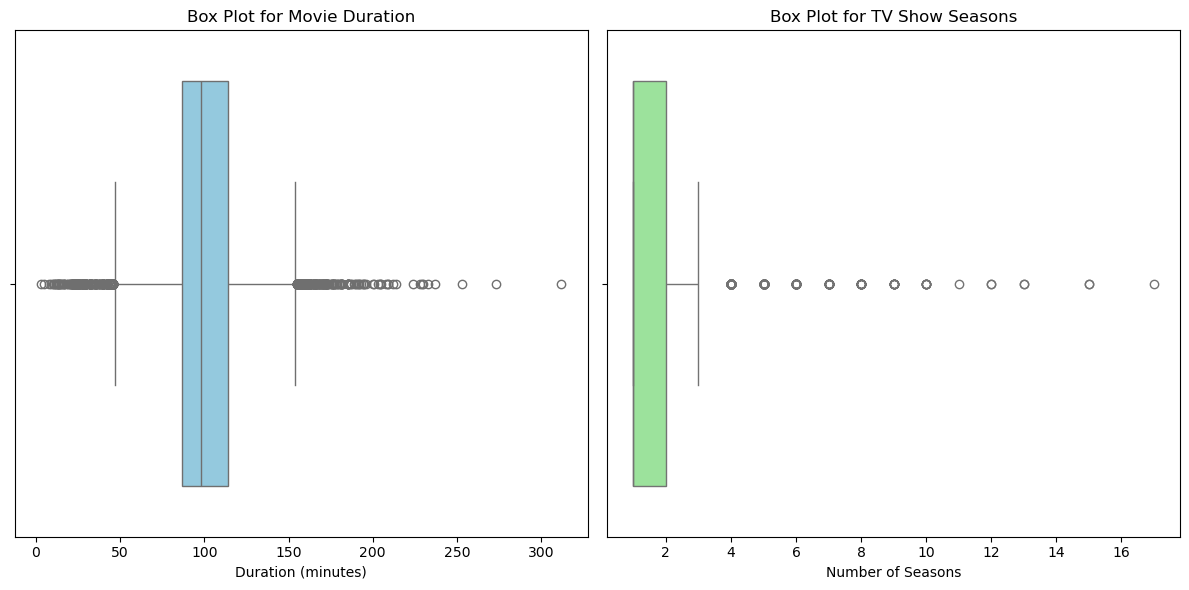

In [82]:
# Filter the data for movies and TV shows separately
movies = df_clean[df_clean['type'] == 'Movie']
tv_shows = df_clean[df_clean['type'] == 'TV Show']

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Box plot for movie duration
sns.boxplot(data=movies, x='movie_duration', ax=axes[0], color='skyblue')
axes[0].set_title('Box Plot for Movie Duration')
axes[0].set_xlabel('Duration (minutes)')

# Box plot for TV show seasons
sns.boxplot(data=tv_shows, x='tv_show_seasons', ax=axes[1], color='lightgreen')
axes[1].set_title('Box Plot for TV Show Seasons')
axes[1].set_xlabel('Number of Seasons')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [ ]:
def movie_api_length(row):
    if row['type'] == 'Movie':
        params['t'] = row['title']
        r = requests.get(url, params).json()
        runtime = r.get('Runtime', None)
        if runtime:
            dur = int(runtime.split()[0])
        if dur == row['movie_duration']:
            return True
        else:
            return False

In [ ]:
df_api_clean['duration_check'] = df_api_clean.apply(movie_api_length, axis=1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added,movie_duration,tv_show_seasons,minimum_age,duration_check


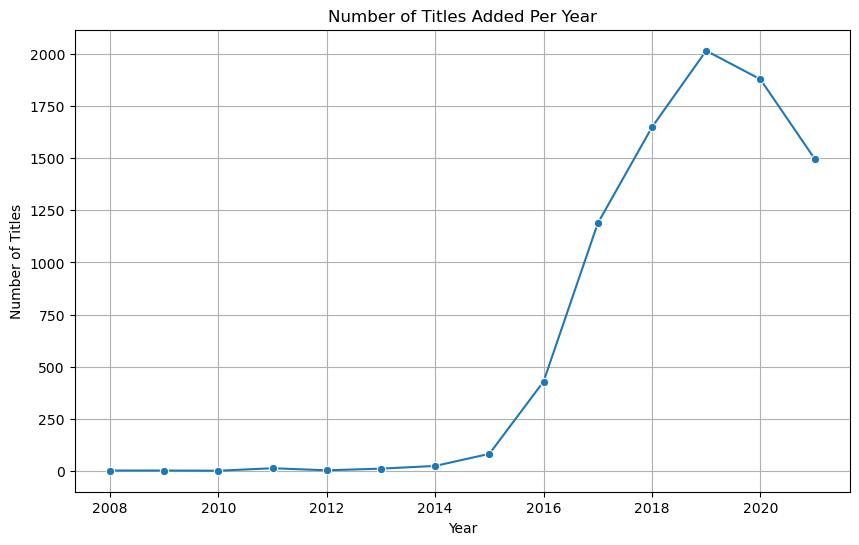

In [97]:
# Count the number of titles added per year
content_per_year = df_clean.groupby('year_added')['title'].count()

# Plot the data
plt.figure(figsize=(10, 6))
sns.lineplot(x=content_per_year.index, y=content_per_year.values, marker='o')
plt.title('Number of Titles Added Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid()
plt.show()

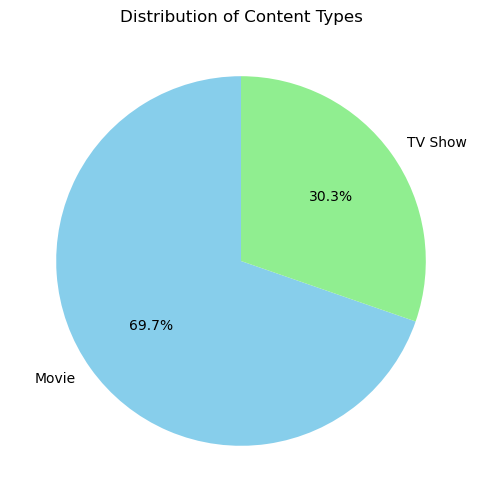

In [98]:
# Count the number of movies and TV shows
content_type_counts = df_clean['type'].value_counts()

# Plot the data
plt.figure(figsize=(8, 6))
content_type_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen'])
plt.title('Distribution of Content Types')
plt.ylabel('')
plt.show()

C:\Users\ldtic\AppData\Local\Temp\ipykernel_12584\1229195879.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_genres, x='Count', y='Genre', palette='viridis')


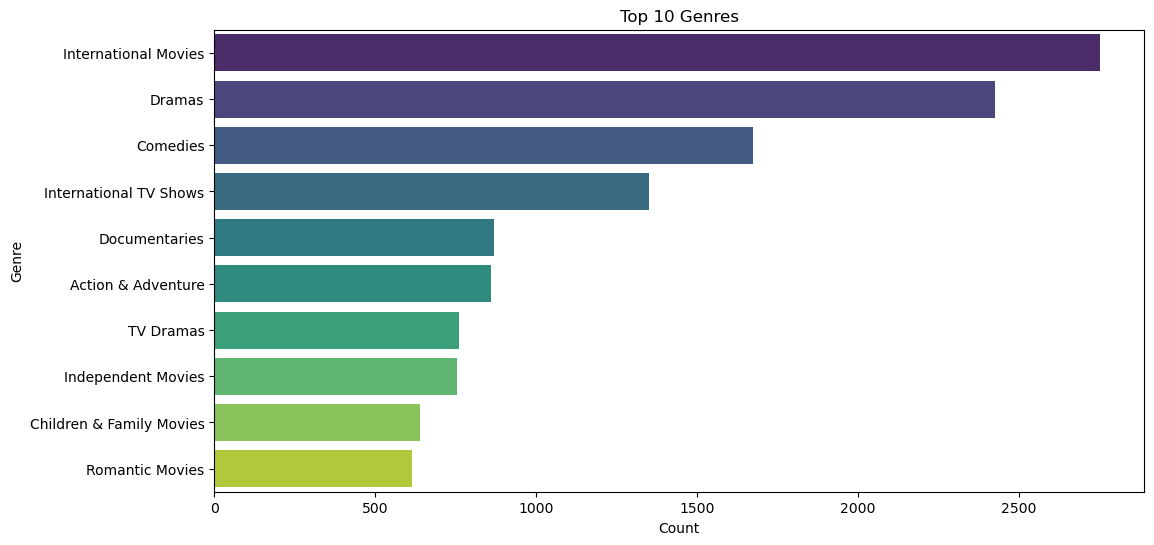

In [99]:
# Flatten the list of genres and count occurrences
from collections import Counter
genre_counts = Counter([genre for sublist in df_clean['listed_in'].dropna() for genre in sublist])

# Get the top 10 genres
top_genres = pd.DataFrame(genre_counts.most_common(10), columns=['Genre', 'Count'])

# Plot the data
plt.figure(figsize=(12, 6))
sns.barplot(data=top_genres, x='Count', y='Genre', palette='viridis')
plt.title('Top 10 Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

C:\Users\ldtic\AppData\Local\Temp\ipykernel_12584\3212020665.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='Count', y='Country', palette='coolwarm')


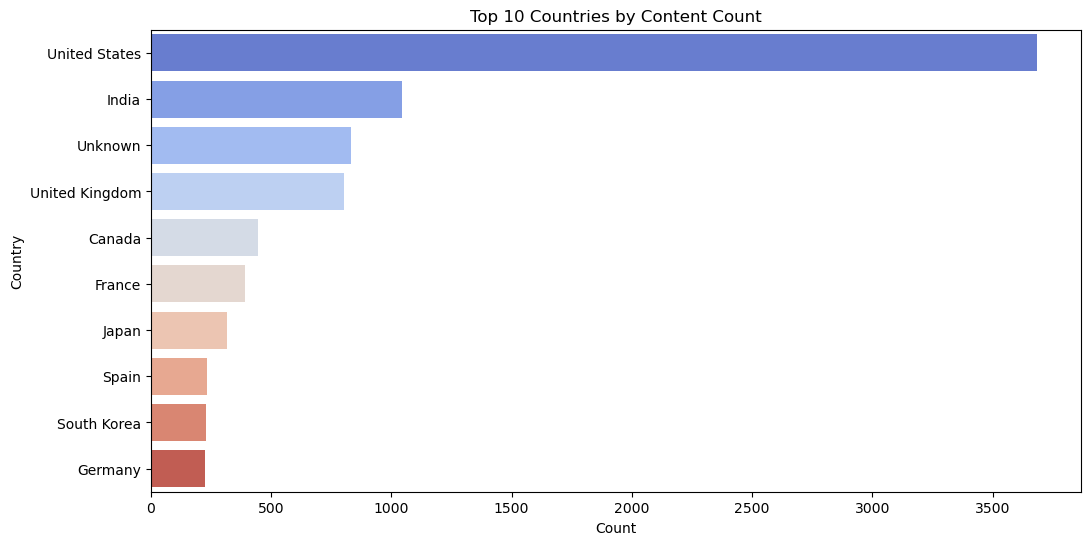

In [100]:
# Flatten the list of countries and count occurrences
country_counts = Counter([country for sublist in df_clean['country'].dropna() for country in sublist])

# Get the top 10 countries
top_countries = pd.DataFrame(country_counts.most_common(10), columns=['Country', 'Count'])

# Plot the data
plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries, x='Count', y='Country', palette='coolwarm')
plt.title('Top 10 Countries by Content Count')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()

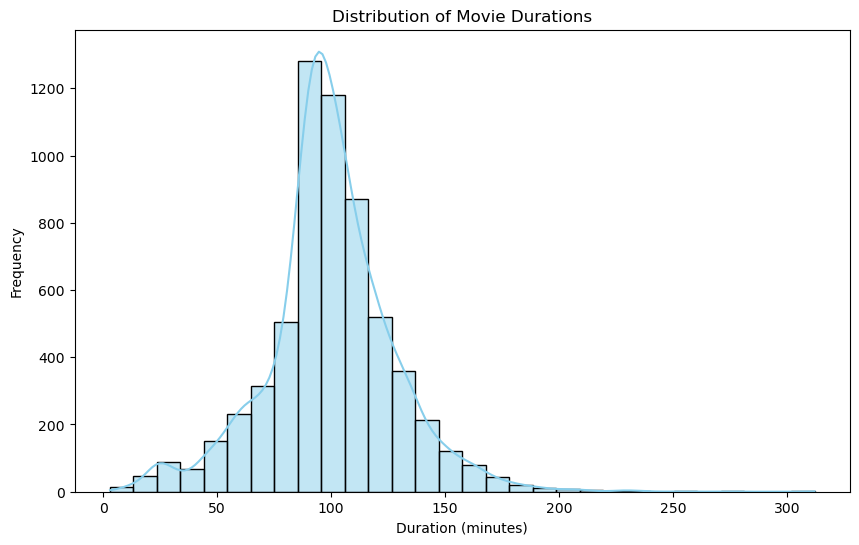

In [101]:
# Plot the distribution of movie durations
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['movie_duration'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

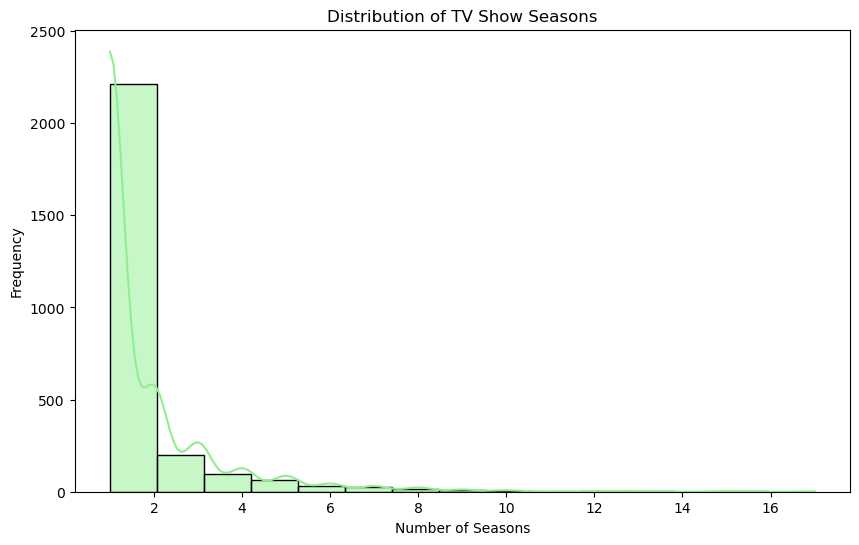

In [102]:
# Plot the distribution of TV show seasons
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['tv_show_seasons'].dropna(), bins=15, kde=True, color='lightgreen')
plt.title('Distribution of TV Show Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Frequency')
plt.show()

C:\Users\ldtic\AppData\Local\Temp\ipykernel_12584\1145349685.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='muted')


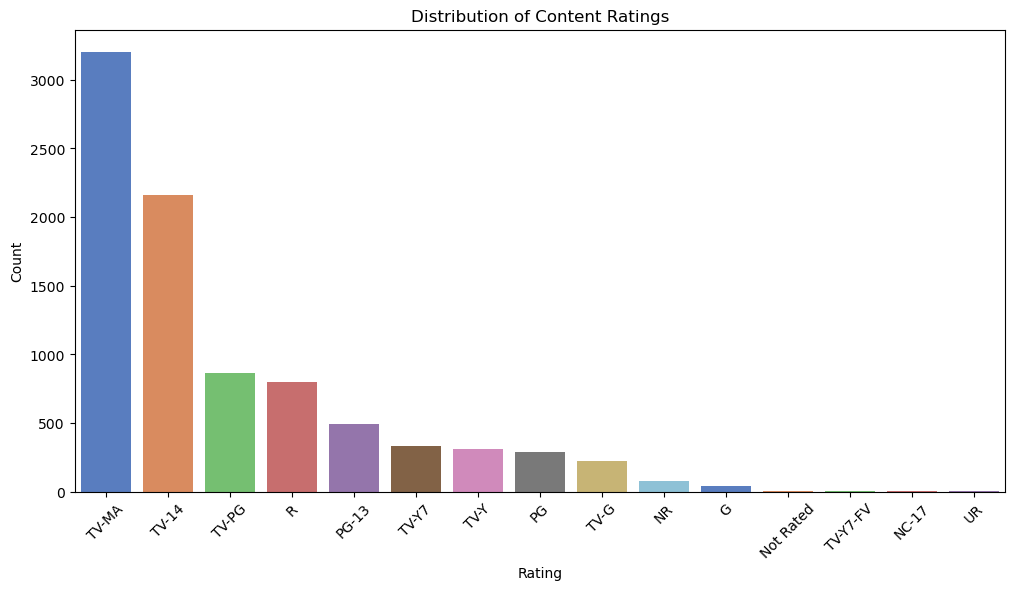

In [103]:
# Count the number of titles for each rating
rating_counts = df_clean['rating'].value_counts()

# Plot the data
plt.figure(figsize=(12, 6))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='muted')
plt.title('Distribution of Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

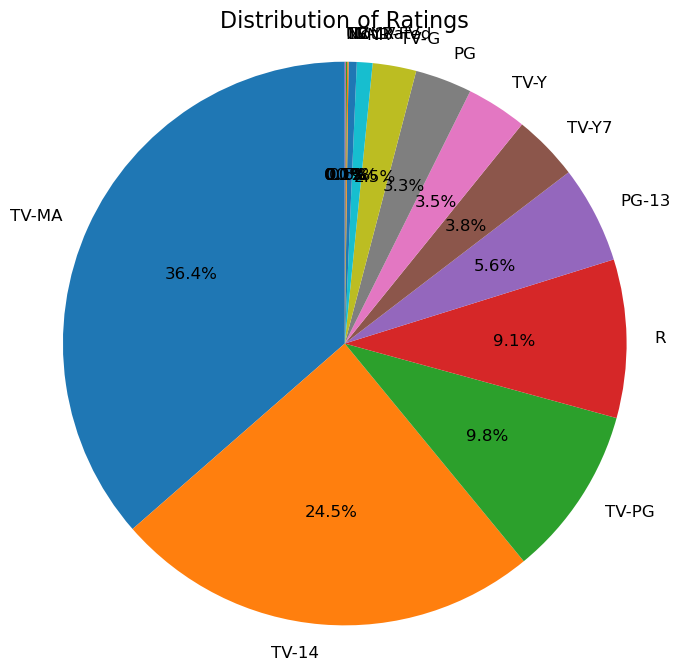

In [153]:
# Group the data by 'rating' and calculate the count
rating_counts = df_clean['rating'].value_counts()

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    rating_counts.values, 
    labels=rating_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    textprops={'fontsize': 12}
)
plt.title('Distribution of Ratings', fontsize=16)
plt.axis('equal')  # Ensures the pie chart is circular
plt.show()


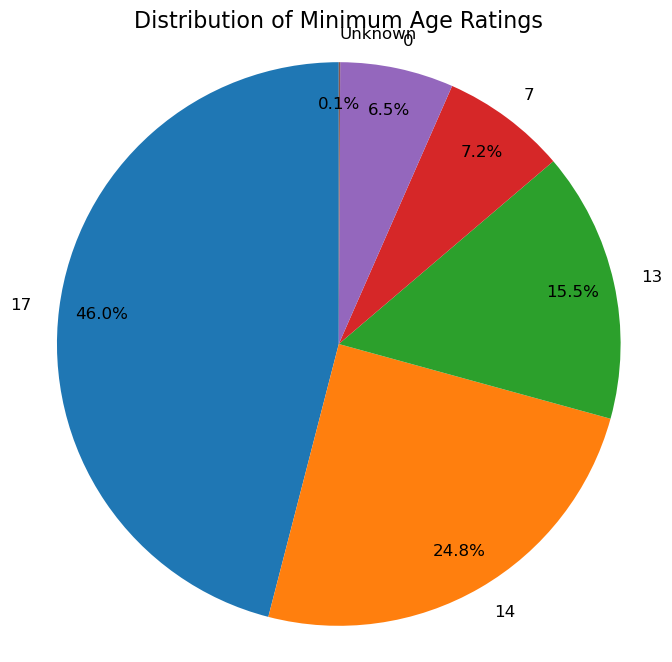

In [156]:
# Group the data by 'minimum_age' and calculate the count
age_counts = df_clean['minimum_age'].value_counts()

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    age_counts.values, 
    labels=age_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    textprops={'fontsize': 12},
    labeldistance=1.1,  # Distance of labels from the center
    pctdistance=0.85    # Distance of percentage values from the center
)
plt.title('Distribution of Minimum Age Ratings', fontsize=16)
plt.axis('equal')  # Ensures the pie chart is circular
plt.show()

C:\Users\ldtic\AppData\Local\Temp\ipykernel_12584\2607620764.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=content_per_month.index, y=content_per_month.values, palette='coolwarm')


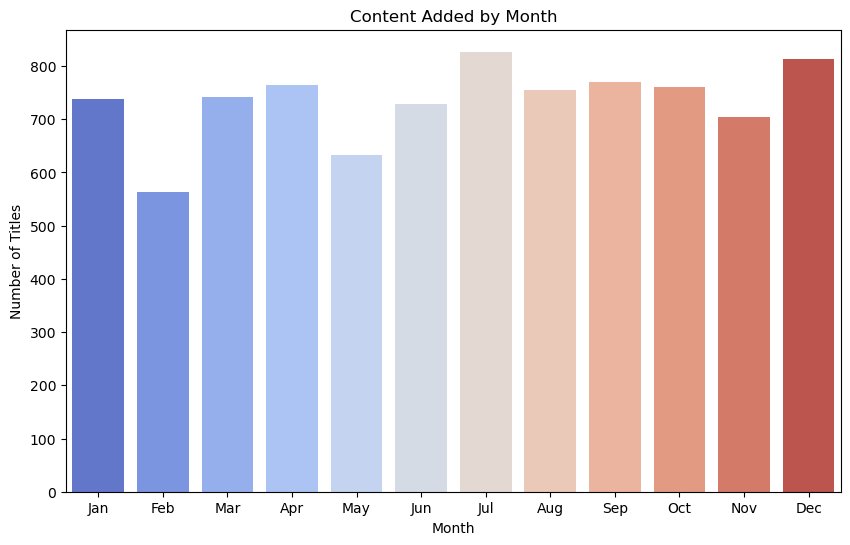

In [104]:
# Count the number of titles added per month
content_per_month = df_clean['month_added'].value_counts().sort_index()

# Plot the data
plt.figure(figsize=(10, 6))
sns.barplot(x=content_per_month.index, y=content_per_month.values, palette='coolwarm')
plt.title('Content Added by Month')
plt.xlabel('Month')
plt.ylabel('Number of Titles')
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

C:\Users\ldtic\AppData\Local\Temp\ipykernel_12584\584667818.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts.index, y=age_counts.values, palette='viridis')


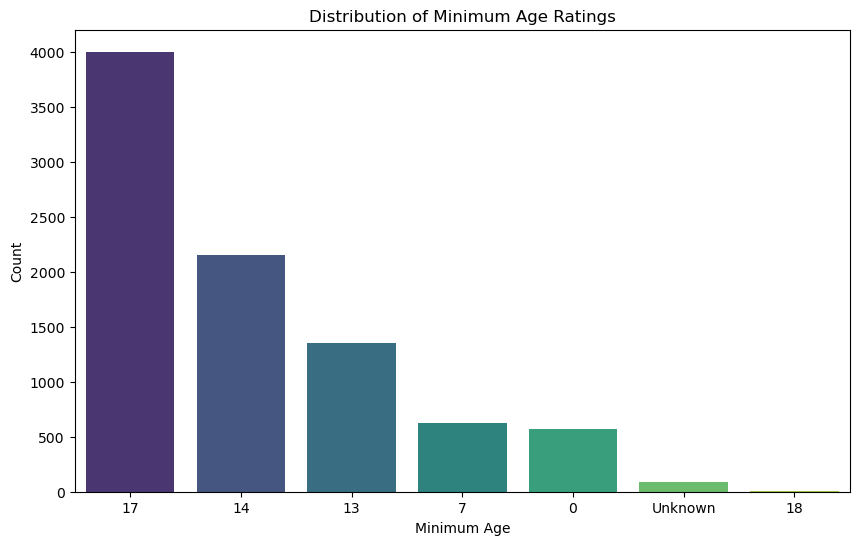

In [106]:
# Count the number of titles for each minimum age group
age_counts = df_clean['minimum_age'].value_counts()

# Plot the data
plt.figure(figsize=(10, 6))
sns.barplot(x=age_counts.index, y=age_counts.values, palette='viridis')
plt.title('Distribution of Minimum Age Ratings')
plt.xlabel('Minimum Age')
plt.ylabel('Count')
plt.show()

In [117]:
import re  # Import regular expressions module

def api_reviews(row):
    params['t'] = row['title']
    try:
        # Make the API request
        r = requests.get(url, params)
        r.raise_for_status()  # Raise an error for bad responses
        response = r.json()

        # Initialize variables for each source
        imdb_rating = None
        rt_rating = None
        mc_rating = None

        # Check if 'Ratings' exists in the response
        if 'Ratings' in response:
            for rating in response['Ratings']:
                source = rating.get('Source')
                value = rating.get('Value')

                # Extract numerical values based on the source
                if source == 'Internet Movie Database':
                    imdb_rating = float(value.split('/')[0])  # Extract the number before '/'
                elif source == 'Rotten Tomatoes':
                    rt_rating = int(value.strip('%'))  # Remove '%' and convert to integer
                elif source == 'Metacritic':
                    mc_rating = int(value.split('/')[0])  # Extract the number before '/'

        # Return the extracted ratings
        return [imdb_rating, rt_rating, mc_rating]

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data for title: {row['title']}, Error: {e}")
        return [None, None, None]

In [118]:
api_reviews(df_clean.iloc[0])
df_clean.iloc[0]

show_id                                                           s1
type                                                           Movie
title                                           Dick Johnson Is Dead
director                                             Kirsten Johnson
cast                                                             NaN
country                                              [United States]
date_added                                       2021-09-25 00:00:00
release_year                                                    2020
rating                                                         PG-13
duration                                                      90 min
listed_in                                            [Documentaries]
description        As her father nears the end of his life, filmm...
month_added                                                        9
year_added                                                      2021
movie_duration                    

In [119]:
df_api_clean['reviews'] = df_api_clean.apply(api_reviews, axis=1)
df_api_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8797 non-null   object        
 1   type             8797 non-null   object        
 2   title            8797 non-null   object        
 3   director         6988 non-null   object        
 4   cast             8210 non-null   object        
 5   country          8797 non-null   object        
 6   date_added       8797 non-null   datetime64[ns]
 7   release_year     8797 non-null   int64         
 8   rating           8797 non-null   object        
 9   duration         8797 non-null   object        
 10  listed_in        8797 non-null   object        
 11  description      8797 non-null   object        
 12  month_added      8797 non-null   int32         
 13  year_added       8797 non-null   int32         
 14  movie_duration   6131 non-null   float64

In [121]:
df_api_clean[['imdb_rating', 'rt_rating', 'mc_rating']] = pd.DataFrame(df_api_clean['reviews'].tolist(), index=df_api_clean.index)
df_api_clean.drop(columns=['reviews'], inplace=True)
df_api_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,description,month_added,year_added,movie_duration,tv_show_seasons,minimum_age,duration_check,imdb_rating,rt_rating,mc_rating
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,"[Michael Hilow, Ana Hoffman, Dick Johnson]",[United States],2021-09-25,2020,PG-13,90 min,...,"As her father nears the end of his life, filmm...",9,2021,90.0,NaN,13,89.0,7.4,99.0,89.0
1,s2,TV Show,Blood & Water,N/A,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",[South Africa],2021-09-24,2021,TV-MA,2 Seasons,...,"After crossing paths at a party, a Cape Town t...",9,2021,NaN,2.0,17,NaN,6.7,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab...",[Unknown],2021-09-24,2021,TV-MA,1 Season,...,To protect his family from a powerful drug lor...,9,2021,NaN,1.0,17,NaN,7.2,NaN,NaN
3,s4,TV Show,Jailbirds New Orleans,N/A,[N/A],[Unknown],2021-09-24,2021,TV-MA,1 Season,...,"Feuds, flirtations and toilet talk go down amo...",9,2021,NaN,1.0,17,NaN,6.5,NaN,NaN
4,s5,TV Show,Kota Factory,N/A,"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam ...",[India],2021-09-24,2021,TV-MA,2 Seasons,...,In a city of coaching centers known to train I...,9,2021,NaN,2.0,17,NaN,9.0,NaN,NaN


In [122]:
df_api_clean.to_csv('data/netflix_titles_clean.csv', index=False)

In [124]:
# Ensure the ratings are numeric and handle missing values
df_api_clean['imdb_rating'] = pd.to_numeric(df_api_clean['imdb_rating'], errors='coerce')
df_api_clean['rt_rating'] = pd.to_numeric(df_api_clean['rt_rating'], errors='coerce')
df_api_clean['mc_rating'] = pd.to_numeric(df_api_clean['mc_rating'], errors='coerce')

# Calculate the average rating for each row
df_api_clean['average_rating'] = df_api_clean[['imdb_rating', 'rt_rating', 'mc_rating']].mean(axis=1)

# Count the number of ratings for each director
df_api_clean['rating_count'] = df_api_clean[['imdb_rating', 'rt_rating', 'mc_rating']].notnull().sum(axis=1)

# Group by director and calculate the weighted average rating and total rating count
director_ratings = df_api_clean.groupby('director').agg(
    total_rating_count=('rating_count', 'sum'),  # Total number of ratings
    weighted_average_rating=('average_rating', 'mean')  # Average of average ratings
).reset_index()

# Calculate a score that combines the weighted average and total rating count
director_ratings['popularity_score'] = director_ratings['weighted_average_rating'] * director_ratings['total_rating_count']

# Find the director with the highest popularity score
most_popular_director = director_ratings.loc[director_ratings['popularity_score'].idxmax()]

# Display the result
print(f"The most popular director is {most_popular_director['director']} with a popularity score of {most_popular_director['popularity_score']:.2f}.")

The most popular director is N/A with a popularity score of 4900.80.


In [125]:
# Ensure the ratings are numeric and handle missing values
df_api_clean['imdb_rating'] = pd.to_numeric(df_api_clean['imdb_rating'], errors='coerce')
df_api_clean['rt_rating'] = pd.to_numeric(df_api_clean['rt_rating'], errors='coerce')
df_api_clean['mc_rating'] = pd.to_numeric(df_api_clean['mc_rating'], errors='coerce')

# Calculate the average rating for each row
df_api_clean['average_rating'] = df_api_clean[['imdb_rating', 'rt_rating', 'mc_rating']].mean(axis=1)

# Explode the 'cast' column to create one row per cast member
df_cast = df_api_clean.explode('cast')

# Remove rows where 'cast' is NaN
df_cast = df_cast[df_cast['cast'].notna()]

# Group by cast member and calculate the total rating count and weighted average rating
cast_ratings = df_cast.groupby('cast').agg(
    total_rating_count=('average_rating', 'count'),  # Count of ratings for each cast member
    weighted_average_rating=('average_rating', 'mean')  # Average of ratings for each cast member
).reset_index()

# Calculate a popularity score that combines the weighted average and total rating count
cast_ratings['popularity_score'] = cast_ratings['weighted_average_rating'] * cast_ratings['total_rating_count']

# Find the cast member with the highest popularity score
most_popular_cast = cast_ratings.loc[cast_ratings['popularity_score'].idxmax()]

# Display the result
print(f"The most popular cast member is {most_popular_cast['cast']} with a popularity score of {most_popular_cast['popularity_score']:.2f}.")

The most popular cast member is Samuel L. Jackson with a popularity score of 840.10.


In [135]:
# Ensure the ratings are numeric and handle missing values
df_api_clean['imdb_rating'] = pd.to_numeric(df_api_clean['imdb_rating'], errors='coerce')
df_api_clean['rt_rating'] = pd.to_numeric(df_api_clean['rt_rating'], errors='coerce')
df_api_clean['mc_rating'] = pd.to_numeric(df_api_clean['mc_rating'], errors='coerce')

# Calculate the average rating for each row
df_api_clean['average_rating'] = df_api_clean[['imdb_rating', 'rt_rating', 'mc_rating']].mean(axis=1)

# Function to find the most popular value for a given column
def find_most_popular(column, top_n=1):
    # Explode the column if it contains lists
    exploded_df = df_api_clean.explode(column) if column in ['listed_in', 'country', 'cast'] else df_api_clean
    exploded_df.dropna(subset=[column], inplace=True)  # Drop rows where the column is NaN
    # Group by the column and calculate metrics
    grouped = exploded_df.groupby(column).agg(
        total_rating_count=('average_rating', 'count'),
        weighted_average_rating=('average_rating', 'mean')
    ).reset_index()
    
    # Calculate the popularity score
    grouped['popularity_score'] = grouped['weighted_average_rating'] * grouped['total_rating_count']
    
    # Return the top N results based on the popularity score
    return grouped.nlargest(top_n, 'popularity_score')

find_most_popular('cast', top_n=5)

,cast,total_rating_count,weighted_average_rating,popularity_score
29991,Samuel L. Jackson,21,40.004762,840.100000
30884,Shah Rukh Khan,31,22.074194,684.300000
18887,Kristen Stewart,17,38.472549,654.033333
11037,Fred Armisen,19,33.569298,637.816667
14270,James Franco,18,34.915741,628.483333


In [137]:
find_most_popular('director', top_n=2)

,director,total_rating_count,weighted_average_rating,popularity_score
3015,N/A,695,7.051511,4900.800000
2730,Martin Scorsese,10,58.476667,584.766667


In [139]:
director = find_most_popular('director', top_n=2)
cast = find_most_popular('cast', top_n=5)
type = find_most_popular('type', top_n=1)
lited_in = find_most_popular('listed_in', top_n=1)
duration = find_most_popular('duration', top_n=1)
print(f'I recommend that a {type.iloc[0]["type"]} is created directed by {director.iloc[1]["director"]} and stars {cast["cast"].to_list()}. the films should be a {lited_in.iloc[0]["listed_in"]} with a duration of {duration.iloc[0]["duration"]}.')


I recommend that a Movie is created directed by Martin Scorsese and stars ['Samuel L. Jackson', 'Shah Rukh Khan', 'Kristen Stewart', 'James Franco', 'Amy Adams']. the films should be a Dramas with a duration of 1 Season.


In [141]:
def find_most_popular(column, top_n=1, filter_by=None, filter_value=None):
    """
    Finds the most popular values in a specified column based on a popularity score.
    
    Parameters:
        column (str): The column to analyze.
        top_n (int): The number of top results to return.
        filter_by (str): The column to filter by (e.g., 'type').
        filter_value (str): The value to filter on (e.g., 'Movie' or 'TV Show').
    
    Returns:
        pd.DataFrame: A DataFrame containing the top N most popular values.
    """
    # Filter the DataFrame if a filter is specified
    filtered_df = df_api_clean.copy()
    if filter_by and filter_value:
        filtered_df = filtered_df[filtered_df[filter_by] == filter_value]
    
    # Explode the column if it contains lists
    if column in ['listed_in', 'country', 'cast']:
        filtered_df = filtered_df.explode(column)
    
    # Drop rows where the column is NaN
    filtered_df = filtered_df.dropna(subset=[column])
    
    # Group by the column and calculate metrics
    grouped = filtered_df.groupby(column).agg(
        total_rating_count=('average_rating', 'count'),
        weighted_average_rating=('average_rating', 'mean')
    ).reset_index()
    
    # Calculate the popularity score
    grouped['popularity_score'] = grouped['weighted_average_rating'] * grouped['total_rating_count']
    
    # Return the top N results based on the popularity score
    return grouped.nlargest(top_n, 'popularity_score')

In [146]:
m_director = find_most_popular('director', top_n=1, filter_by='type', filter_value='Movie')
m_cast = find_most_popular('cast', top_n=5, filter_by='type', filter_value='Movie')
m_lited_in = find_most_popular('listed_in', top_n=1, filter_by='type', filter_value='Movie')
m_duration = find_most_popular('movie_duration', top_n=1, filter_by='type', filter_value='Movie')
m_month_added = find_most_popular('month_added', top_n=1, filter_by='type', filter_value='Movie')
m_country = find_most_popular('country', top_n=1, filter_by='type', filter_value='Movie')
m_rating = find_most_popular('rating', top_n=1, filter_by='type', filter_value='Movie')

print(m_director.iloc[0]['director'])
print(m_cast['cast'].to_list())
print(m_lited_in.iloc[0]['listed_in'])
print(m_duration.iloc[0]['movie_duration'])
print(m_month_added.iloc[0]['month_added'])
print(m_country.iloc[0]['country'])
print(m_rating.iloc[0]['rating'])

Martin Scorsese
['Samuel L. Jackson', 'Shah Rukh Khan', 'Kristen Stewart', 'James Franco', 'Amy Adams']
Dramas
94.0
1.0
United States
TV-MA


In [149]:
tv_director = find_most_popular('director', top_n=5, filter_by='type', filter_value='TV Show')
tv_cast = find_most_popular('cast', top_n=5, filter_by='type', filter_value='TV Show')
tv_lited_in = find_most_popular('listed_in', top_n=1, filter_by='type', filter_value='TV Show')
tv_duration = find_most_popular('tv_show_seasons', top_n=1, filter_by='type', filter_value='TV Show')
tv_month_added = find_most_popular('month_added', top_n=1, filter_by='type', filter_value='TV Show')
tv_country = find_most_popular('country', top_n=1, filter_by='type', filter_value='TV Show')
tv_rating = find_most_popular('rating', top_n=1, filter_by='type', filter_value='TV Show')

print(tv_director.iloc[1]['director'])
print(tv_cast['cast'].to_list())
print(tv_lited_in.iloc[0]['listed_in'])
print(tv_duration.iloc[0]['tv_show_seasons'])
print(tv_month_added.iloc[0]['month_added'])
print(tv_country.iloc[0]['country'])
print(tv_rating.iloc[0]['rating'])

Ken Burns
['Yuki Kaji', 'Daisuke Ono', 'Sam Waterston', 'Junichi Suwabe', 'Arthur Miller']
International TV Shows
1.0
6.0
United States
TV-MA
